In [ ]:
!pip -q install openpyxl scikit-learn

In [ ]:
import os
import copy
import pickle
import zipfile
import shutil
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import files

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

OUTPUT_ROOT = "GeoFormer_outputs_1_2_4_heads"

if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Carpeta raíz de salida limpia:", OUTPUT_ROOT)

Dispositivo: cpu
Carpeta raíz de salida limpia: GeoFormer_outputs_1_2_4_heads


In [ ]:

def save_current_figure(output_path_png, dpi=300):
    """
    Guarda la figura actual en PNG y SVG.

    Si output_path_png termina en .png, también se crea
    una versión .svg con el mismo nombre base.
    """
    output_path_png = str(output_path_png)
    output_path_svg = output_path_png.replace(".png", ".svg")

    plt.savefig(
        output_path_png,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.savefig(
        output_path_svg,
        format="svg",
        bbox_inches="tight"
    )

    return output_path_png, output_path_svg

In [ ]:
uploaded = files.upload()

excel_path = list(uploaded.keys())[0]
df = pd.read_excel(excel_path)

df.columns = df.columns.str.strip()

ID_COL = "fid"
TARGET_COL = "class"
CAT_COLS = ["UGS", "GMF", "CLC", "SLOPE"]
GROUP_COL = None

excluded_cols = [ID_COL, TARGET_COL] + CAT_COLS
if GROUP_COL is not None:
    excluded_cols.append(GROUP_COL)

NUM_COLS = [c for c in df.columns if c not in excluded_cols]

print("Archivo cargado:", excel_path)
print("Dimensiones:", df.shape)

print("\nVariable ID:")
print(ID_COL)

print("\nVariable objetivo:")
print(TARGET_COL)

print("\nVariables categóricas de la frase geoambiental:")
for col in CAT_COLS:
    print(f"- {col}: str")

print("\nVariables continuas:")
for col in NUM_COLS:
    print(f"- {col}: float64")

display(df.head())
print("\nTipos originales leídos desde el Excel:")
print(df.dtypes)

Saving DataPaul.xlsx to DataPaul.xlsx
Archivo cargado: DataPaul.xlsx
Dimensiones: (400, 10)

Variable ID:
fid

Variable objetivo:
class

Variables categóricas de la frase geoambiental:
- UGS: str
- GMF: str
- CLC: str
- SLOPE: str

Variables continuas:
- TRI: float64
- TWI: float64
- Curvature: float64
- Elevation: float64


,fid,UGS,GMF,CLC,SLOPE,TRI,TWI,Curvature,Elevation,class
0,1,Srccsb,Sgf,31122.0,6,7.158911,2.103482,0.0128,1554,1
1,2,Rbmca,Dmc,2311.0,5,3.605551,2.897750,0.0256,2164,1
2,3,Srccp,Vla,232.0,5,5.220153,3.082989,-0.0128,2317,1
3,4,Srccp,Vla,32222.0,5,3.535534,3.946606,0.0000,2336,1
4,5,Srccp,Vle,232.0,5,3.535534,2.845010,0.0000,2274,1



Tipos originales leídos desde el Excel:
fid            int64
UGS           object
GMF           object
CLC          float64
SLOPE          int64
TRI          float64
TWI          float64
Curvature    float64
Elevation      int64
class          int64
dtype: object


In [ ]:
ID_COL = "fid"
TARGET_COL = "class"

CAT_COLS = ["UGS", "GMF", "CLC", "SLOPE"]

GROUP_COL = None

excluded_cols = [ID_COL, TARGET_COL] + CAT_COLS
if GROUP_COL is not None:
    excluded_cols.append(GROUP_COL)

NUM_COLS = [c for c in df.columns if c not in excluded_cols]

print("ID:", ID_COL)
print("Target:", TARGET_COL)
print("Categóricas:", CAT_COLS)
print("Continuas:", NUM_COLS)

ID: fid
Target: class
Categóricas: ['UGS', 'GMF', 'CLC', 'SLOPE']
Continuas: ['TRI', 'TWI', 'Curvature', 'Elevation']


In [ ]:
df = df.copy()

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

def clean_category_value(v):
    if pd.isna(v):
        return "__MISSING__"
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    return str(v).strip()

for col in CAT_COLS:
    df[col] = df[col].apply(clean_category_value).astype(str)

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Distribución de la variable objetivo:")
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True))

Distribución de la variable objetivo:
class
1    269
0    131
Name: count, dtype: int64
class
1    0.6725
0    0.3275
Name: proportion, dtype: float64


In [ ]:
indices = np.arange(len(df))
y_all = df[TARGET_COL].values

# Train = 75 %
VALIDATION_SIZE = 0.25

if GROUP_COL is not None and GROUP_COL in df.columns:
    print("Usando separación por grupos espaciales:", GROUP_COL)

    groups = df[GROUP_COL].values

    # Esto evita que muestras de un mismo bloque espacial queden mezcladas entre train y validation.
    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_SIZE,
        random_state=SEED
    )

    train_idx, val_idx = next(
        gss_val.split(df, y_all, groups=groups)
    )

else:
    print("Usando separación estratificada aleatoria.")
    print("Para validación espacial estricta, agrega una columna de bloque espacial.")

    train_idx, val_idx = train_test_split(
        indices,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        stratify=y_all
    )

print("Train:", len(train_idx), f"({len(train_idx) / len(df):.1%})")
print("Validation:", len(val_idx), f"({len(val_idx) / len(df):.1%})")

print("\nDistribución train:")
print(df.iloc[train_idx][TARGET_COL].value_counts())

print("\nDistribución validation:")
print(df.iloc[val_idx][TARGET_COL].value_counts())

Usando separación estratificada aleatoria.
Para validación espacial estricta, agrega una columna de bloque espacial.
Train: 300 (75.0%)
Validation: 100 (25.0%)

Distribución train:
class
1    202
0     98
Name: count, dtype: int64

Distribución validation:
class
1    67
0    33
Name: count, dtype: int64


In [ ]:
cat_maps = {}

for col in CAT_COLS:
    train_values = sorted(df.iloc[train_idx][col].unique())

    mapping = {"__UNK__": 0}

    for i, value in enumerate(train_values, start=1):
        mapping[value] = i

    cat_maps[col] = mapping

vocab_sizes = [len(cat_maps[col]) for col in CAT_COLS]

print("Tamaños de vocabulario:")
for col, size in zip(CAT_COLS, vocab_sizes):
    print(f"{col}: {size}")

def encode_categorical(frame):
    arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.int64)

    for j, col in enumerate(CAT_COLS):
        mapping = cat_maps[col]
        arr[:, j] = frame[col].apply(lambda v: mapping.get(v, 0)).values

    return arr

Tamaños de vocabulario:
UGS: 32
GMF: 30
CLC: 36
SLOPE: 8


In [ ]:
if len(NUM_COLS) > 0:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_num_train_raw = df.iloc[train_idx][NUM_COLS]
    X_num_train_imp = imputer.fit_transform(X_num_train_raw)
    scaler.fit(X_num_train_imp)

    def transform_numeric(frame):
        x_imp = imputer.transform(frame[NUM_COLS])
        x_scaled = scaler.transform(x_imp)
        return x_scaled.astype(np.float64)

else:
    imputer = None
    scaler = None

    def transform_numeric(frame):
        return np.zeros((len(frame), 0), dtype=np.float64)

In [ ]:
X_cat = encode_categorical(df)
X_num = transform_numeric(df)
y = df[TARGET_COL].values.astype(np.float64)

X_cat_train, X_num_train, y_train = X_cat[train_idx], X_num[train_idx], y[train_idx]
X_cat_val, X_num_val, y_val = X_cat[val_idx], X_num[val_idx], y[val_idx]

print("X_cat_train:", X_cat_train.shape)
print("X_num_train:", X_num_train.shape)
print("y_train:", y_train.shape)

print("X_cat_val:", X_cat_val.shape)
print("X_num_val:", X_num_val.shape)
print("y_val:", y_val.shape)

X_cat_train: (300, 4)
X_num_train: (300, 4)
y_train: (300,)
X_cat_val: (100, 4)
X_num_val: (100, 4)
y_val: (100,)


In [ ]:
class GeoFormerDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float64)
        self.y = torch.tensor(y, dtype=torch.float64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [ ]:
class GeoFormerAttentionBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        ff_dim,
        dropout
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout_attn = nn.Dropout(dropout)
        self.dropout_ffn = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x, return_attention=False):
        x_norm = self.norm1(x)

        attn_out, attn_weights = self.self_attn(
            x_norm,
            x_norm,
            x_norm,
            need_weights=return_attention,
            average_attn_weights=False
        )

        x = x + self.dropout_attn(attn_out)

        x_norm = self.norm2(x)
        x = x + self.dropout_ffn(self.ffn(x_norm))

        if return_attention:
            return x, attn_weights

        return x, None


class GeoFormer(nn.Module):
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=1,
        ff_dim=48,
        num_proj_dim=8,
        mlp_hidden=24,
        dropout=0.35,
        pooling="mean"
    ):
        super().__init__()

        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        assert pooling in ["mean", "cls"], "pooling debe ser 'mean' o 'cls'"

        self.vocab_sizes = vocab_sizes
        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric
        self.d_model = d_model
        self.pooling = pooling

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        self.factor_embedding = nn.Embedding(self.num_categorical, d_model)

        self.cat_input_norm = nn.LayerNorm(d_model)
        self.cat_dropout = nn.Dropout(dropout)

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        self.transformer_encoder = nn.ModuleList([
            GeoFormerAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.cat_output_norm = nn.LayerNorm(d_model)

        if num_numeric > 0:
            self.numeric_branch = nn.Sequential(
                nn.Linear(num_numeric, num_proj_dim),
                nn.LayerNorm(num_proj_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            fusion_dim = d_model + num_proj_dim
        else:
            self.numeric_branch = None
            fusion_dim = d_model

        self.prediction_head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, max(mlp_hidden // 2, 4)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(mlp_hidden // 2, 4), 1)
        )

        self._reset_parameters()

    def _reset_parameters(self):
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0.0, std=0.02)

        nn.init.normal_(self.factor_embedding.weight, mean=0.0, std=0.02)

        if self.cls_token is not None:
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x_cat, x_num, return_attention=False):
        batch_size = x_cat.size(0)

        token_list = []
        for j, emb in enumerate(self.embeddings):
            token_j = emb(x_cat[:, j])
            token_list.append(token_j)

        z = torch.stack(token_list, dim=1)

        factor_ids = torch.arange(
            self.num_categorical,
            device=x_cat.device
        ).unsqueeze(0).expand(batch_size, -1)

        z = z + self.factor_embedding(factor_ids)
        z = self.cat_input_norm(z)
        z = self.cat_dropout(z)

        if self.pooling == "cls":
            cls = self.cls_token.expand(batch_size, -1, -1)
            z = torch.cat([cls, z], dim=1)

        attention_layers = []

        for encoder_block in self.transformer_encoder:
            z, attn_weights = encoder_block(
                z,
                return_attention=return_attention
            )

            if return_attention:
                attention_layers.append(attn_weights)

        z = self.cat_output_norm(z)

        if self.pooling == "mean":
            h_cat = z.mean(dim=1)
        else:
            h_cat = z[:, 0, :]

        if self.numeric_branch is not None:
            h_num = self.numeric_branch(x_num)
            h = torch.cat([h_cat, h_num], dim=1)
        else:
            h = h_cat

        logits = self.prediction_head(h).squeeze(1)

        if return_attention:
            attention = torch.stack(attention_layers, dim=0)
            return logits, attention

        return logits

In [ ]:
BASE_HYPERPARAMS = {
    "d_model": 16,

    "n_heads": None,

    "n_layers": 1,
    "ff_dim": 56,
    "num_proj_dim": 12,
    "mlp_hidden": 28,
    "dropout": 0.34,
    "pooling": "mean",

    "lr": 2.5e-4,

    "weight_decay": 5e-3,

    "epochs": 150,
    "patience": 7,
    "min_delta": 1e-4,

    "batch_size": 32,
    "max_grad_norm": 1.5,

    "threshold_metric": "min_errors"
}

VARIANTS = {
    "single_head_attention": {
        "label": "Single-head attention (1 head)",
        "n_heads": 1
    },
    "multi_head_2_attention": {
        "label": "Multi-head attention (2 heads)",
        "n_heads": 2
    },
    "multi_head_4_attention": {
        "label": "Multi-head attention (4 heads)",
        "n_heads": 4
    }
}

BASE_HYPERPARAMS, VARIANTS

({'d_model': 16,
  'n_heads': None,
  'n_layers': 1,
  'ff_dim': 56,
  'num_proj_dim': 12,
  'mlp_hidden': 28,
  'dropout': 0.34,
  'pooling': 'mean',
  'lr': 0.00025,
  'weight_decay': 0.005,
  'epochs': 150,
  'patience': 7,
  'min_delta': 0.0001,
  'batch_size': 32,
  'max_grad_norm': 1.5,
  'threshold_metric': 'min_errors'},
 {'single_head_attention': {'label': 'Single-head attention (1 head)',
   'n_heads': 1},
  'multi_head_2_attention': {'label': 'Multi-head attention (2 heads)',
   'n_heads': 2},
  'multi_head_4_attention': {'label': 'Multi-head attention (4 heads)',
   'n_heads': 4}})

In [ ]:

def make_loaders(batch_size, seed=42):
    train_ds = GeoFormerDataset(X_cat_train, X_num_train, y_train)
    val_ds = GeoFormerDataset(X_cat_val, X_num_val, y_val)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        generator=generator
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader


def evaluate_loader(model, loader, criterion):
    model.eval()

    all_y = []
    all_probs = []
    losses = []

    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in loader:
            x_cat_batch = x_cat_batch.to(device)
            x_num_batch = x_num_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_cat_batch, x_num_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            losses.append(loss.item() * len(y_batch))
            all_y.append(y_batch.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_probs = np.concatenate(all_probs)

    mean_loss = np.sum(losses) / len(all_y)

    return mean_loss, all_y, all_probs


def train_one_epoch(model, loader, criterion, optimizer, max_grad_norm):
    model.train()

    losses = []

    for x_cat_batch, x_num_batch, y_batch in loader:
        x_cat_batch = x_cat_batch.to(device)
        x_num_batch = x_num_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_cat_batch, x_num_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm
        )

        optimizer.step()

        losses.append(loss.item() * len(y_batch))

    return np.sum(losses) / len(loader.dataset)


def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_average_precision(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "AUC": safe_auc(y_true, y_prob),
        "AUPRC": safe_average_precision(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, metric="min_errors"):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = 0.5
    best_score = -np.inf

    report = []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        total_errors = fp + fn

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)

        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)

        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)

        elif metric == "youden":
            sensitivity = tp / (tp + fn + 1e-12)
            specificity = tn / (tn + fp + 1e-12)
            score = sensitivity + specificity - 1

        elif metric == "min_errors":
            score = -total_errors + 1e-3 * balanced_accuracy_score(y_true, y_pred)

        else:
            raise ValueError("metric debe ser: f1, accuracy, balanced_accuracy, youden o min_errors")

        report.append({
            "threshold": th,
            "metric": metric,
            "score": score,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "total_errors": total_errors
        })

        if score > best_score:
            best_score = score
            best_threshold = th

    report_df = pd.DataFrame(report)

    return best_threshold, best_score, report_df


def summarize_thresholds(y_true, y_prob):
    rows = []

    for metric in ["f1", "accuracy", "balanced_accuracy", "youden", "min_errors"]:
        th, score, _ = find_best_threshold(y_true, y_prob, metric=metric)
        y_pred = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "metric": metric,
            "threshold": th,
            "score": score,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "total_errors": fp + fn
        })

    return pd.DataFrame(rows)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:

def predict_arrays(model, X_cat_array, X_num_array, batch_size=512):
    model.eval()

    probs_all = []

    X_cat_tensor = torch.tensor(X_cat_array, dtype=torch.long)
    X_num_tensor = torch.tensor(X_num_array, dtype=torch.float64)

    with torch.no_grad():
        for start in range(0, len(X_cat_tensor), batch_size):
            end = start + batch_size

            x_cat_batch = X_cat_tensor[start:end].to(device)
            x_num_batch = X_num_tensor[start:end].to(device)

            logits = model(x_cat_batch, x_num_batch)
            probs = torch.sigmoid(logits)

            probs_all.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_all)


def get_attention_token_labels(model, cat_cols):
    if model.pooling == "cls":
        return ["CLS"] + list(cat_cols)
    return list(cat_cols)


def collect_attention_outputs(
    model,
    X_cat_array,
    X_num_array,
    batch_size=512
):
    model.eval()

    probs_all = []
    attention_all = []

    X_cat_tensor = torch.tensor(X_cat_array, dtype=torch.long)
    X_num_tensor = torch.tensor(X_num_array, dtype=torch.float64)

    with torch.no_grad():
        for start in range(0, len(X_cat_tensor), batch_size):
            end = start + batch_size

            x_cat_batch = X_cat_tensor[start:end].to(device)
            x_num_batch = X_num_tensor[start:end].to(device)

            logits, attention = model(
                x_cat_batch,
                x_num_batch,
                return_attention=True
            )

            probs = torch.sigmoid(logits)

            attention = attention.mean(dim=(0, 2))

            probs_all.append(probs.detach().cpu().numpy())
            attention_all.append(attention.detach().cpu().numpy())

    probs_all = np.concatenate(probs_all)
    attention_all = np.concatenate(attention_all, axis=0)

    return probs_all, attention_all


def plot_attention_matrix(matrix, labels, title, output_path):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(matrix)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(
        ticks=np.arange(len(labels)),
        labels=labels,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        ticks=np.arange(len(labels)),
        labels=labels
    )

    plt.xlabel("Token atendido")
    plt.ylabel("Token que atiende")
    plt.title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    save_current_figure(output_path, dpi=300)
    plt.show()


def save_attention_analysis(model, variant_name, output_dir, best_threshold):
    attention_probs, attention_by_sample = collect_attention_outputs(
        model=model,
        X_cat_array=X_cat,
        X_num_array=X_num,
        batch_size=512
    )

    attention_labels = get_attention_token_labels(model, CAT_COLS)
    attention_mean = attention_by_sample.mean(axis=0)

    attention_matrix_df = pd.DataFrame(
        attention_mean,
        index=[f"query_{label}" for label in attention_labels],
        columns=[f"key_{label}" for label in attention_labels]
    )

    attention_matrix_path = os.path.join(output_dir, "attention_matrix_mean.xlsx")
    attention_matrix_df.to_excel(attention_matrix_path)

    plot_attention_matrix(
        matrix=attention_mean,
        labels=attention_labels,
        title=f"Atención promedio - {variant_name}",
        output_path=os.path.join(output_dir, "attention_matrix_mean.png")
    )

    attention_received = attention_mean.mean(axis=0)
    attention_given = attention_mean.mean(axis=1)
    self_attention = np.diag(attention_mean)

    attention_by_variable_df = pd.DataFrame({
        "variant": variant_name,
        "variable": attention_labels,
        "attention_received_mean": attention_received,
        "attention_given_mean": attention_given,
        "self_attention": self_attention
    }).sort_values(
        "attention_received_mean",
        ascending=False
    ).reset_index(drop=True)

    attention_by_variable_df.to_excel(
        os.path.join(output_dir, "attention_by_variable.xlsx"),
        index=False
    )

    attention_class_rows = []
    attention_class_matrices = {}

    for class_value in sorted(np.unique(y).astype(int)):
        mask = y.astype(int) == class_value

        if mask.sum() == 0:
            continue

        class_matrix = attention_by_sample[mask].mean(axis=0)
        attention_class_matrices[class_value] = class_matrix

        plot_attention_matrix(
            matrix=class_matrix,
            labels=attention_labels,
            title=f"Atención promedio - {variant_name} - clase {class_value}",
            output_path=os.path.join(
                output_dir,
                f"attention_matrix_class_{class_value}.png"
            )
        )

        received = class_matrix.mean(axis=0)
        given = class_matrix.mean(axis=1)
        self_att = np.diag(class_matrix)

        for i, variable in enumerate(attention_labels):
            attention_class_rows.append({
                "variant": variant_name,
                "class": class_value,
                "variable": variable,
                "attention_received_mean": received[i],
                "attention_given_mean": given[i],
                "self_attention": self_att[i],
                "n_samples": int(mask.sum())
            })

    attention_by_class_df = pd.DataFrame(attention_class_rows)
    attention_by_class_df.to_excel(
        os.path.join(output_dir, "attention_by_class.xlsx"),
        index=False
    )

    if 0 in attention_class_matrices and 1 in attention_class_matrices:
        attention_difference = attention_class_matrices[1] - attention_class_matrices[0]

        attention_difference_df = pd.DataFrame(
            attention_difference,
            index=[f"query_{label}" for label in attention_labels],
            columns=[f"key_{label}" for label in attention_labels]
        )

        attention_difference_df.to_excel(
            os.path.join(output_dir, "attention_matrix_class_1_minus_class_0.xlsx")
        )

        plot_attention_matrix(
            matrix=attention_difference,
            labels=attention_labels,
            title=f"Diferencia de atención clase 1 - clase 0 - {variant_name}",
            output_path=os.path.join(
                output_dir,
                "attention_matrix_class_1_minus_class_0.png"
            )
        )

    sample_attention_received = attention_by_sample.mean(axis=1)

    sample_attention_df = df[[ID_COL] + CAT_COLS + [TARGET_COL]].copy()
    sample_attention_df["variant"] = variant_name
    sample_attention_df["prob_susceptibilidad"] = attention_probs
    sample_attention_df["pred_class"] = (
        sample_attention_df["prob_susceptibilidad"].values >= best_threshold
    ).astype(int)

    for i, variable in enumerate(attention_labels):
        sample_attention_df[f"attention_received_{variable}"] = sample_attention_received[:, i]

    attention_columns = [
        f"attention_received_{variable}"
        for variable in attention_labels
    ]

    sample_attention_df["dominant_attention_variable"] = (
        sample_attention_df[attention_columns]
        .idxmax(axis=1)
        .str.replace("attention_received_", "", regex=False)
    )

    sample_attention_df["geoenvironmental_phrase"] = (
        sample_attention_df[CAT_COLS]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    sample_attention_df.to_excel(
        os.path.join(output_dir, "attention_by_sample.xlsx"),
        index=False
    )

    return {
        "attention_by_variable_df": attention_by_variable_df,
        "attention_by_class_df": attention_by_class_df,
        "sample_attention_df": sample_attention_df
    }

In [ ]:

def run_geoformer_experiment(variant_key, variant_info):
    variant_label = variant_info["label"]
    n_heads = variant_info["n_heads"]

    print("=" * 80)
    print(f"Ejecutando variante: {variant_label} | n_heads={n_heads}")
    print("=" * 80)

    set_seed(SEED)

    output_dir = os.path.join(OUTPUT_ROOT, variant_key)
    os.makedirs(output_dir, exist_ok=True)

    hparams = BASE_HYPERPARAMS.copy()
    hparams["n_heads"] = n_heads

    train_loader, val_loader = make_loaders(
        batch_size=hparams["batch_size"],
        seed=SEED
    )

    model = GeoFormer(
        vocab_sizes=vocab_sizes,
        num_numeric=X_num_train.shape[1],
        d_model=hparams["d_model"],
        n_heads=hparams["n_heads"],
        n_layers=hparams["n_layers"],
        ff_dim=hparams["ff_dim"],
        num_proj_dim=hparams["num_proj_dim"],
        mlp_hidden=hparams["mlp_hidden"],
        dropout=hparams["dropout"],
        pooling=hparams["pooling"]
    ).to(device).double()

    n_params = count_trainable_parameters(model)

    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    pos_weight_value = n_neg / max(n_pos, 1)

    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float64,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hparams["lr"],
        weight_decay=hparams["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    best_val_loss = np.inf
    best_state = None
    best_epoch = 0
    patience_counter = 0
    history = []

    start_time = time.time()

    for epoch in range(1, hparams["epochs"] + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_grad_norm=hparams["max_grad_norm"]
        )

        val_loss, val_y_eval, val_probs = evaluate_loader(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        val_auc = safe_auc(val_y_eval, val_probs)

        history.append({
            "variant": variant_label,
            "n_heads": n_heads,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
            "lr": current_lr
        })

        improved = val_loss < best_val_loss - hparams["min_delta"]

        if improved:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"{variant_label} | "
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_auc={val_auc:.4f} | "
                f"lr={current_lr:.2e}"
            )

        if patience_counter >= hparams["patience"]:
            print(f"{variant_label} | Early stopping en epoch {epoch}")
            break

    train_time_seconds = time.time() - start_time

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        os.path.join(output_dir, "training_history.csv"),
        index=False
    )

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.title(f"Curva de pérdida - {variant_label}")
    save_current_figure(
        os.path.join(output_dir, "loss_curve.png"),
        dpi=300
    )
    plt.show()

    train_loss, train_y_eval, train_probs = evaluate_loader(
        model,
        train_loader,
        criterion
    )
    val_loss, val_y_eval, val_probs = evaluate_loader(
        model,
        val_loader,
        criterion
    )

    threshold_summary_df = summarize_thresholds(val_y_eval, val_probs)
    threshold_summary_df["variant"] = variant_label
    threshold_summary_df["n_heads"] = n_heads

    best_threshold, best_val_score, threshold_report_df = find_best_threshold(
        val_y_eval,
        val_probs,
        metric=hparams["threshold_metric"]
    )

    train_metrics = compute_metrics(
        train_y_eval,
        train_probs,
        threshold=best_threshold
    )
    val_metrics = compute_metrics(
        val_y_eval,
        val_probs,
        threshold=best_threshold
    )

    val_pred = (val_probs >= best_threshold).astype(int)
    cm = confusion_matrix(val_y_eval, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No landslide", "Landslide"]
    )

    disp.plot()
    plt.title(
        f"Matriz de confusión - {variant_label}\\n"
        f"threshold={best_threshold:.2f} ({hparams['threshold_metric']})"
    )
    save_current_figure(
        os.path.join(output_dir, "confusion_matrix_validation.png"),
        dpi=300
    )
    plt.show()

    metrics_rows = []

    for split_name, metrics_dict, loss_value in [
        ("Train", train_metrics, train_loss),
        ("Validation", val_metrics, val_loss)
    ]:
        row = {
            "variant": variant_label,
            "variant_key": variant_key,
            "n_heads": n_heads,
            "split": split_name,
            "loss": loss_value,
            "best_threshold": best_threshold,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_time_seconds": train_time_seconds,
            "n_trainable_parameters": n_params,
            "TN": tn if split_name == "Validation" else np.nan,
            "FP": fp if split_name == "Validation" else np.nan,
            "FN": fn if split_name == "Validation" else np.nan,
            "TP": tp if split_name == "Validation" else np.nan,
            "validation_errors": (fp + fn) if split_name == "Validation" else np.nan
        }
        row.update(metrics_dict)
        metrics_rows.append(row)

    metrics_df = pd.DataFrame(metrics_rows)

    metrics_df.to_excel(
        os.path.join(output_dir, "metrics.xlsx"),
        index=False
    )

    threshold_summary_df.to_excel(
        os.path.join(output_dir, "threshold_summary.xlsx"),
        index=False
    )

    threshold_report_df.to_excel(
        os.path.join(output_dir, "threshold_report.xlsx"),
        index=False
    )

    all_probs = predict_arrays(model, X_cat, X_num)
    all_pred = (all_probs >= best_threshold).astype(int)

    output_df = df[[ID_COL, TARGET_COL]].copy()
    output_df["variant"] = variant_label
    output_df["n_heads"] = n_heads
    output_df["prob_susceptibilidad"] = all_probs
    output_df["pred_class"] = all_pred

    output_df.to_excel(
        os.path.join(output_dir, "predictions.xlsx"),
        index=False
    )
    output_df.to_csv(
        os.path.join(output_dir, "predictions.csv"),
        index=False
    )

    attention_results = save_attention_analysis(
        model=model,
        variant_name=variant_label,
        output_dir=output_dir,
        best_threshold=best_threshold
    )

    model_package = {
        "model_state_dict": model.state_dict(),
        "vocab_sizes": vocab_sizes,
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS,
        "id_col": ID_COL,
        "target_col": TARGET_COL,
        "hyperparams": hparams,
        "variant": variant_label,
        "n_heads": n_heads,
        "best_threshold": best_threshold,
        "training_mode": "early_stopping_best_validation_loss",
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "n_trainable_parameters": n_params,
        "train_time_seconds": train_time_seconds
    }

    torch.save(
        model_package,
        os.path.join(output_dir, "GeoFormer_model.pt")
    )

    preprocessing_package = {
        "cat_maps": cat_maps,
        "imputer": imputer,
        "scaler": scaler,
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS
    }

    with open(os.path.join(output_dir, "GeoFormer_preprocessing.pkl"), "wb") as f:
        pickle.dump(preprocessing_package, f)

    print(f"Finalizado: {variant_label}")
    print("Mejor epoch:", best_epoch)
    print("Mejor val_loss:", best_val_loss)
    print("Mejor threshold:", best_threshold)
    print("Parámetros entrenables:", n_params)
    print("Tiempo entrenamiento (s):", round(train_time_seconds, 2))

    return {
        "variant_key": variant_key,
        "variant_label": variant_label,
        "n_heads": n_heads,
        "output_dir": output_dir,
        "model": model,
        "history_df": history_df,
        "metrics_df": metrics_df,
        "threshold_summary_df": threshold_summary_df,
        "threshold_report_df": threshold_report_df,
        "predictions_df": output_df,
        "attention_by_variable_df": attention_results["attention_by_variable_df"],
        "attention_by_class_df": attention_results["attention_by_class_df"],
        "best_threshold": best_threshold,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "train_time_seconds": train_time_seconds,
        "n_trainable_parameters": n_params
    }

Ejecutando variante: Single-head attention (1 head) | n_heads=1
Single-head attention (1 head) | Epoch 001 | train_loss=0.5277 | val_loss=0.4697 | val_auc=0.3989 | lr=2.50e-04
Single-head attention (1 head) | Epoch 005 | train_loss=0.4294 | val_loss=0.4082 | val_auc=0.7680 | lr=2.50e-04
Single-head attention (1 head) | Epoch 010 | train_loss=0.3631 | val_loss=0.3216 | val_auc=0.9190 | lr=2.50e-04
Single-head attention (1 head) | Epoch 015 | train_loss=0.3098 | val_loss=0.2328 | val_auc=0.9548 | lr=2.50e-04
Single-head attention (1 head) | Epoch 020 | train_loss=0.2268 | val_loss=0.1800 | val_auc=0.9688 | lr=2.50e-04
Single-head attention (1 head) | Epoch 025 | train_loss=0.1877 | val_loss=0.1496 | val_auc=0.9683 | lr=2.50e-04
Single-head attention (1 head) | Epoch 030 | train_loss=0.1667 | val_loss=0.1406 | val_auc=0.9679 | lr=2.50e-04
Single-head attention (1 head) | Epoch 035 | train_loss=0.1584 | val_loss=0.1465 | val_auc=0.9679 | lr=2.50e-04
Single-head attention (1 head) | Early s

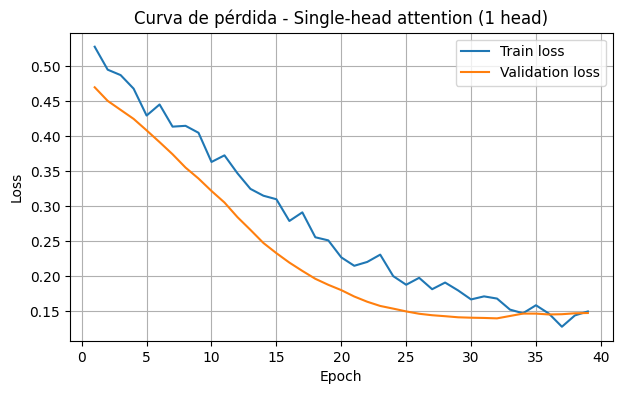

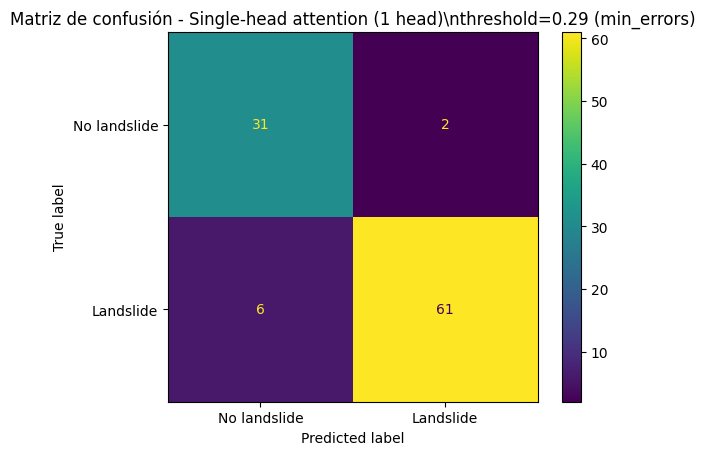

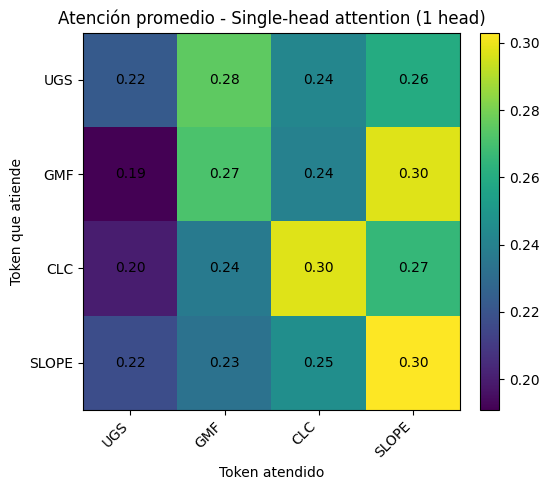

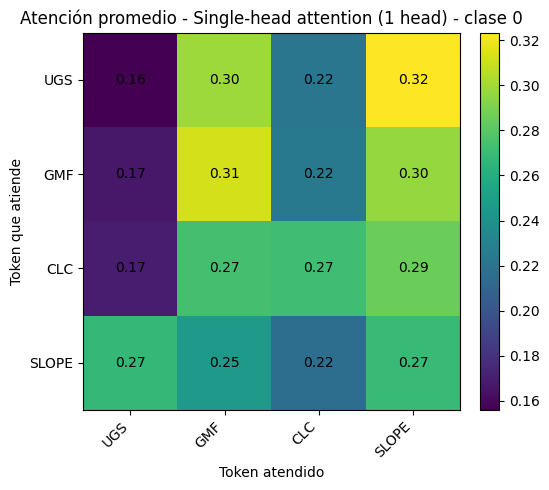

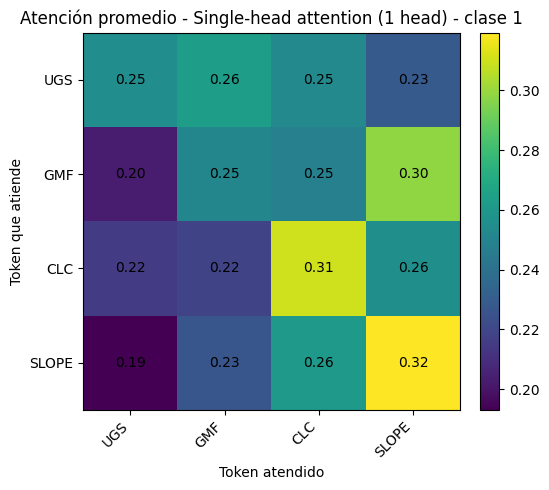

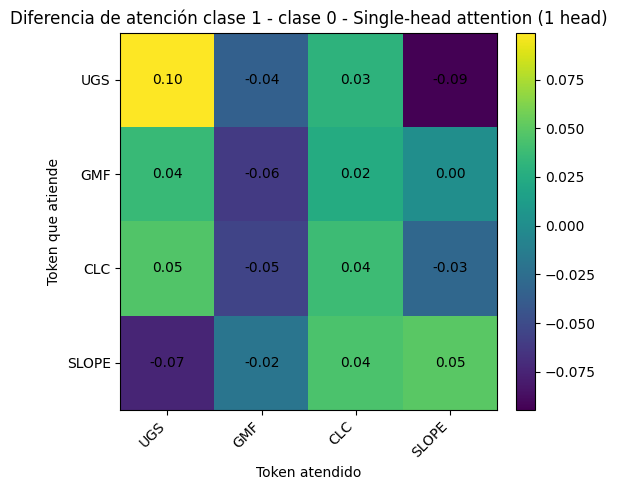

Finalizado: Single-head attention (1 head)
Mejor epoch: 32
Mejor val_loss: 0.13969104503637658
Mejor threshold: 0.29000000000000004
Parámetros entrenables: 6213
Tiempo entrenamiento (s): 7.78
Ejecutando variante: Multi-head attention (2 heads) | n_heads=2
Multi-head attention (2 heads) | Epoch 001 | train_loss=0.5133 | val_loss=0.4699 | val_auc=0.3939 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 005 | train_loss=0.4610 | val_loss=0.3946 | val_auc=0.8100 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 010 | train_loss=0.3385 | val_loss=0.3030 | val_auc=0.9308 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 015 | train_loss=0.2789 | val_loss=0.2189 | val_auc=0.9575 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 020 | train_loss=0.2376 | val_loss=0.1698 | val_auc=0.9656 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 025 | train_loss=0.1909 | val_loss=0.1426 | val_auc=0.9688 | lr=2.50e-04
Multi-head attention (2 heads) | Epoch 030 | train_loss=0.1640 | val_los

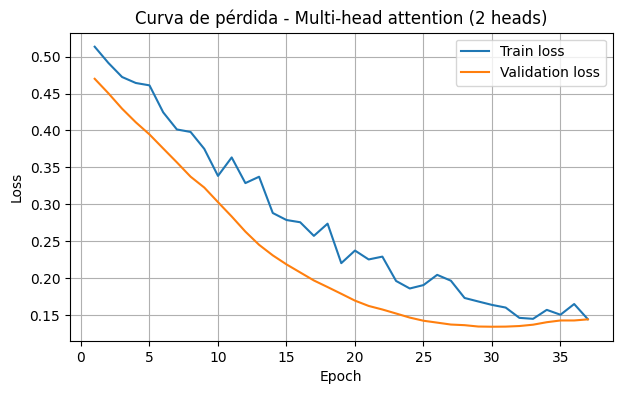

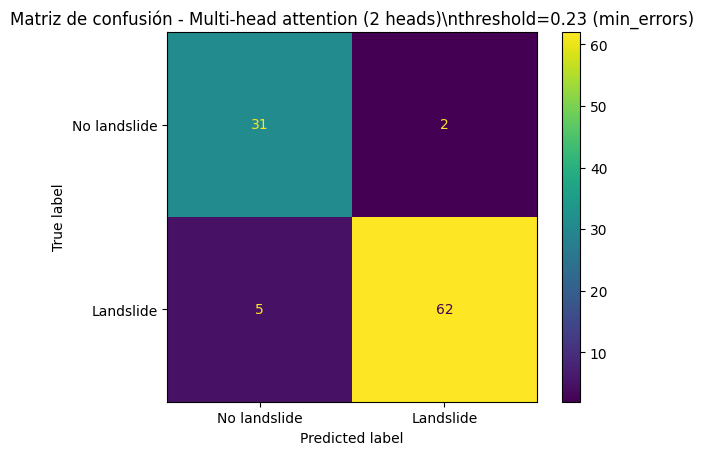

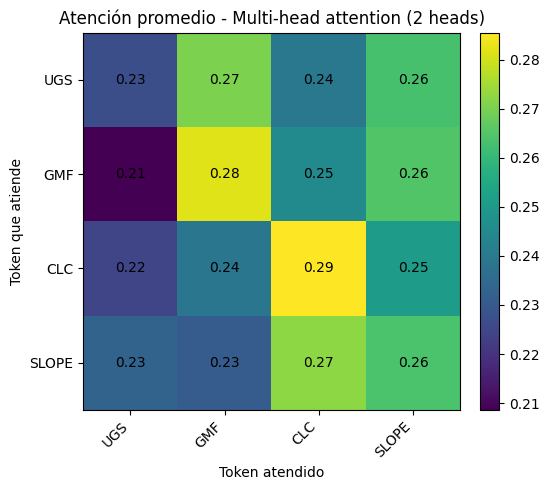

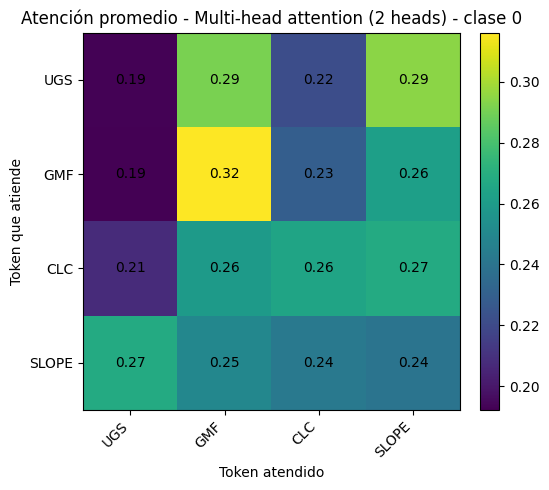

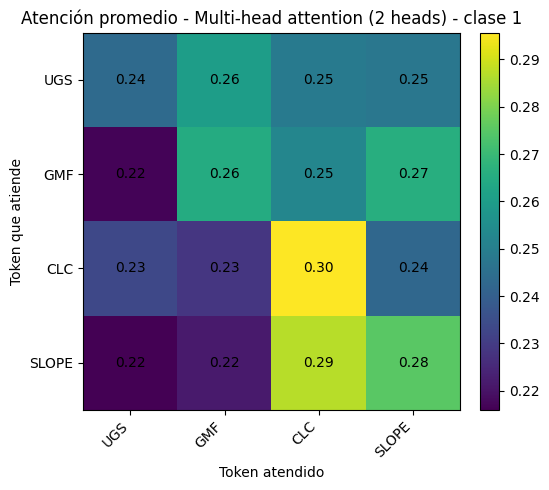

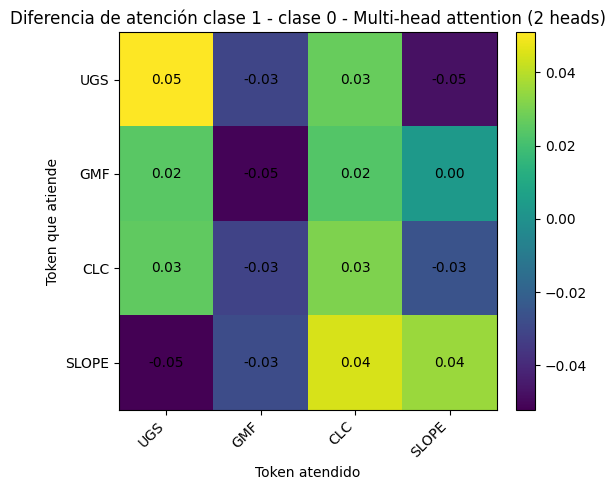

Finalizado: Multi-head attention (2 heads)
Mejor epoch: 30
Mejor val_loss: 0.1345330473144854
Mejor threshold: 0.23
Parámetros entrenables: 6213
Tiempo entrenamiento (s): 3.45
Ejecutando variante: Multi-head attention (4 heads) | n_heads=4
Multi-head attention (4 heads) | Epoch 001 | train_loss=0.5266 | val_loss=0.4724 | val_auc=0.3804 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 005 | train_loss=0.4504 | val_loss=0.4074 | val_auc=0.7675 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 010 | train_loss=0.3646 | val_loss=0.3113 | val_auc=0.9132 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 015 | train_loss=0.2870 | val_loss=0.2241 | val_auc=0.9489 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 020 | train_loss=0.2365 | val_loss=0.1713 | val_auc=0.9620 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 025 | train_loss=0.1807 | val_loss=0.1496 | val_auc=0.9638 | lr=2.50e-04
Multi-head attention (4 heads) | Epoch 030 | train_loss=0.1623 | val_loss=0.1408 | val_a

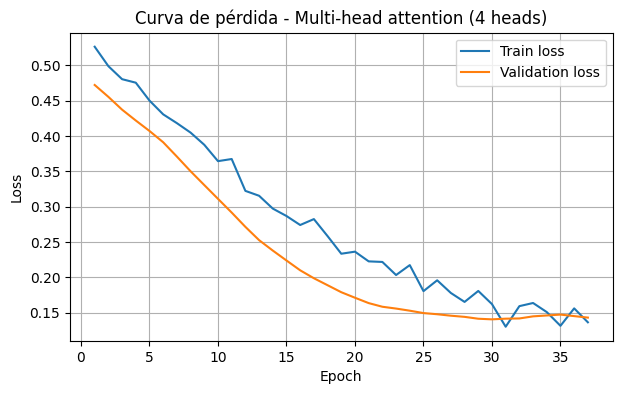

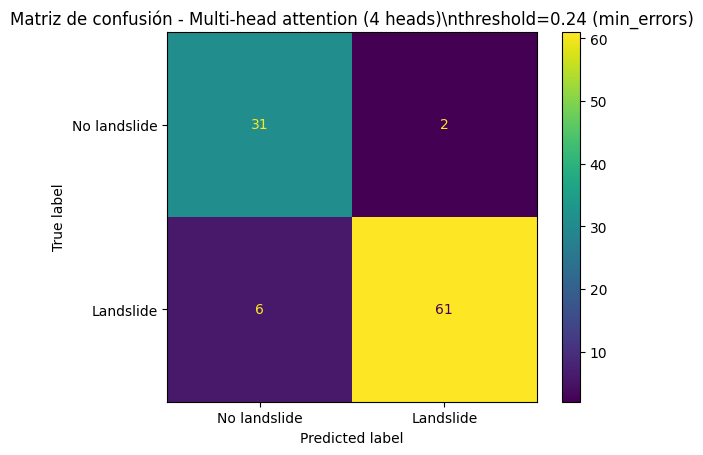

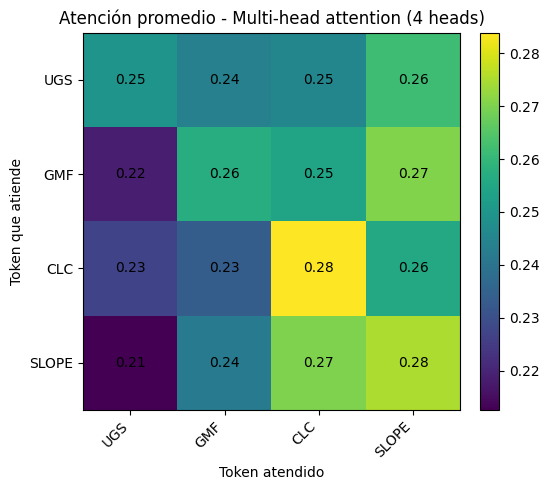

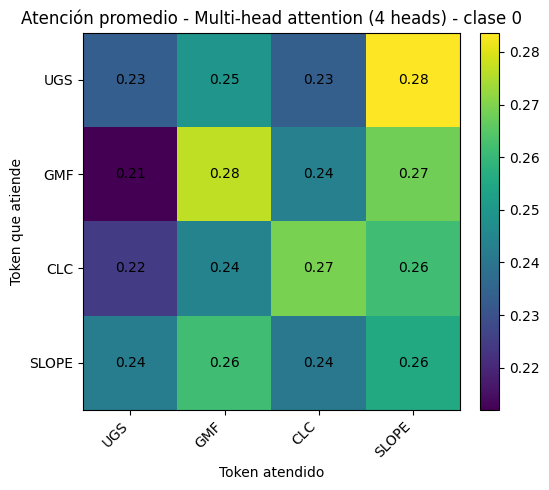

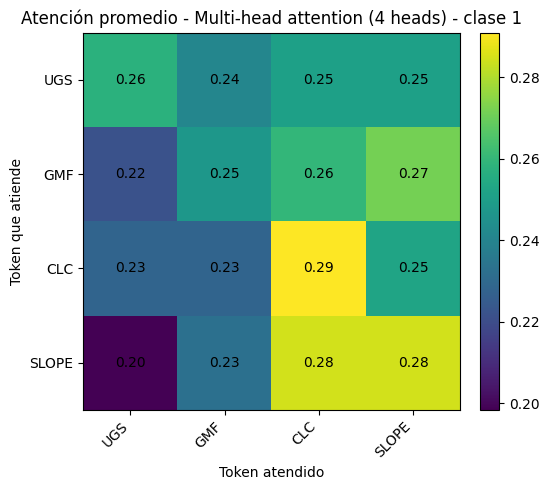

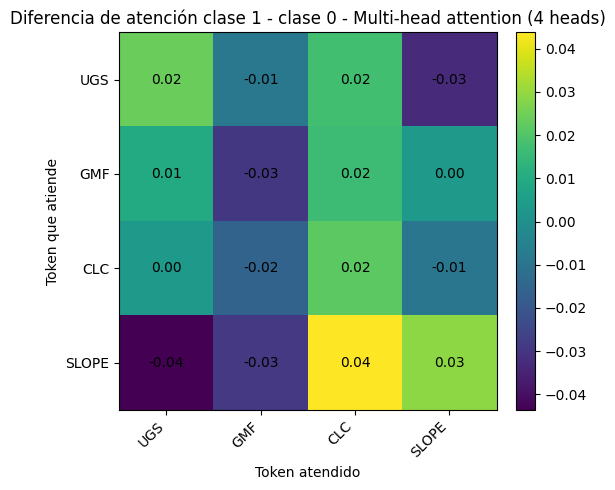

Finalizado: Multi-head attention (4 heads)
Mejor epoch: 30
Mejor val_loss: 0.14076491167675048
Mejor threshold: 0.24000000000000002
Parámetros entrenables: 6213
Tiempo entrenamiento (s): 3.58
Comparación terminada.


In [ ]:

experiment_results = {}

for variant_key, variant_info in VARIANTS.items():
    result = run_geoformer_experiment(
        variant_key=variant_key,
        variant_info=variant_info
    )

    experiment_results[variant_key] = result

print("Comparación terminada.")

In [ ]:

all_metrics_df = pd.concat(
    [result["metrics_df"] for result in experiment_results.values()],
    ignore_index=True
)

all_metrics_path = os.path.join(OUTPUT_ROOT, "all_metrics_1_2_4_heads.xlsx")
all_metrics_df.to_excel(all_metrics_path, index=False)

display(all_metrics_df)

validation_comparison_df = (
    all_metrics_df
    .query("split == 'Validation'")
    .copy()
    .sort_values("n_heads")
    .reset_index(drop=True)
)

validation_comparison_path = os.path.join(
    OUTPUT_ROOT,
    "validation_metrics_comparison_1_2_4_heads.xlsx"
)
validation_comparison_df.to_excel(validation_comparison_path, index=False)

display(validation_comparison_df)

,variant,variant_key,n_heads,split,loss,best_threshold,best_epoch,best_val_loss,train_time_seconds,n_trainable_parameters,...,validation_errors,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
0,Single-head attention (1 head),single_head_attention,1,Train,0.076944,0.29,32,0.139691,7.776954,6213,...,NaN,0.991109,0.996347,0.960000,0.975000,0.965347,0.970149,0.909651,0.957163,0.031250
1,Single-head attention (1 head),single_head_attention,1,Validation,0.139691,0.29,32,0.139691,7.776954,6213,...,8.0,0.966983,0.986022,0.920000,0.968254,0.910448,0.938462,0.827678,0.924921,0.070666
2,Multi-head attention (2 heads),multi_head_2_attention,2,Train,0.086547,0.23,30,0.134533,3.448627,6213,...,NaN,0.990604,0.995982,0.960000,0.970297,0.970297,0.970297,0.909073,0.954536,0.038270
3,Multi-head attention (2 heads),multi_head_2_attention,2,Validation,0.134533,0.23,30,0.134533,3.448627,6213,...,7.0,0.969697,0.987097,0.930000,0.968750,0.925373,0.946565,0.847134,0.932384,0.069498
4,Multi-head attention (4 heads),multi_head_4_attention,4,Train,0.086471,0.24,30,0.140765,3.578831,6213,...,NaN,0.991463,0.996310,0.963333,0.975124,0.970297,0.972705,0.916894,0.959638,0.036030
5,Multi-head attention (4 heads),multi_head_4_attention,4,Validation,0.140765,0.24,30,0.140765,3.578831,6213,...,8.0,0.966079,0.985893,0.920000,0.968254,0.910448,0.938462,0.827678,0.924921,0.071070


,variant,variant_key,n_heads,split,loss,best_threshold,best_epoch,best_val_loss,train_time_seconds,n_trainable_parameters,...,validation_errors,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
0,Single-head attention (1 head),single_head_attention,1,Validation,0.139691,0.29,32,0.139691,7.776954,6213,...,8.0,0.966983,0.986022,0.92,0.968254,0.910448,0.938462,0.827678,0.924921,0.070666
1,Multi-head attention (2 heads),multi_head_2_attention,2,Validation,0.134533,0.23,30,0.134533,3.448627,6213,...,7.0,0.969697,0.987097,0.93,0.968750,0.925373,0.946565,0.847134,0.932384,0.069498
2,Multi-head attention (4 heads),multi_head_4_attention,4,Validation,0.140765,0.24,30,0.140765,3.578831,6213,...,8.0,0.966079,0.985893,0.92,0.968254,0.910448,0.938462,0.827678,0.924921,0.071070


In [ ]:

metric_cols = [
    "loss",
    "AUC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "Brier",
    "best_threshold",
    "best_epoch",
    "best_val_loss",
    "validation_errors",
    "train_time_seconds",
    "n_trainable_parameters"
]

wide_rows = []

for metric in metric_cols:
    row = {"metric": metric}

    for _, r in validation_comparison_df.iterrows():
        row[r["variant"]] = r[metric]

    wide_rows.append(row)

wide_comparison_df = pd.DataFrame(wide_rows)

wide_comparison_path = os.path.join(
    OUTPUT_ROOT,
    "wide_validation_metrics_comparison_1_2_4_heads.xlsx"
)
wide_comparison_df.to_excel(wide_comparison_path, index=False)

display(wide_comparison_df)

,metric,Single-head attention (1 head),Multi-head attention (2 heads),Multi-head attention (4 heads)
0,loss,0.139691,0.134533,0.140765
1,AUC,0.966983,0.969697,0.966079
2,AUPRC,0.986022,0.987097,0.985893
3,Accuracy,0.920000,0.930000,0.920000
4,Precision,0.968254,0.968750,0.968254
5,Recall,0.910448,0.925373,0.910448
6,F1,0.938462,0.946565,0.938462
7,MCC,0.827678,0.847134,0.827678
8,Balanced_Accuracy,0.924921,0.932384,0.924921
9,Brier,0.070666,0.069498,0.071070


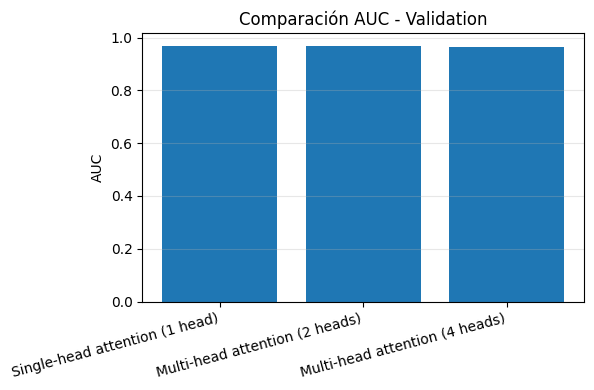

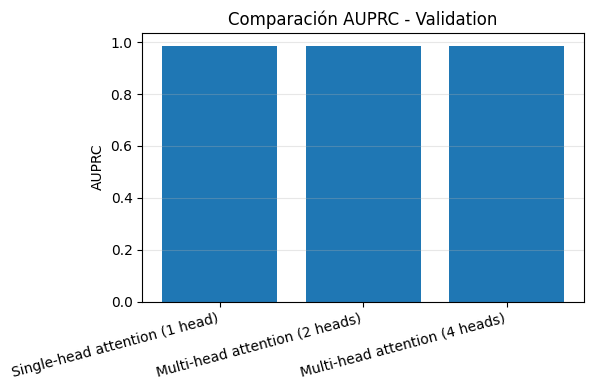

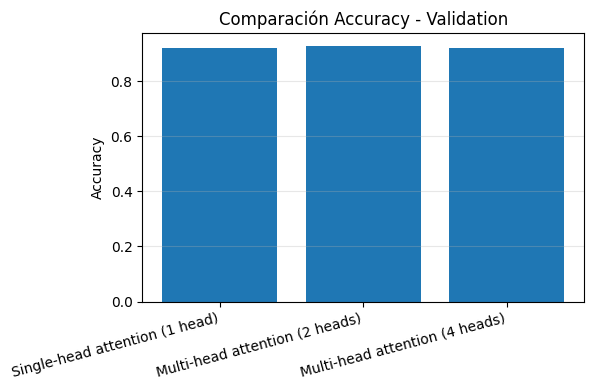

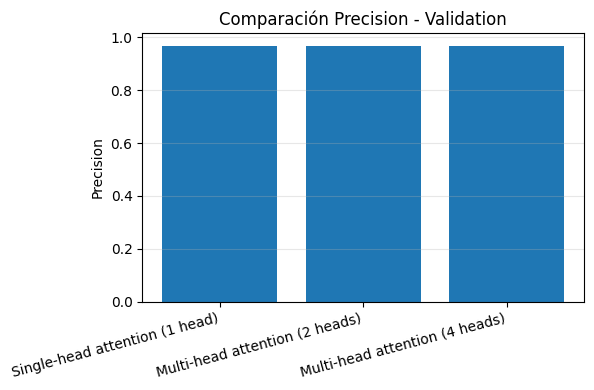

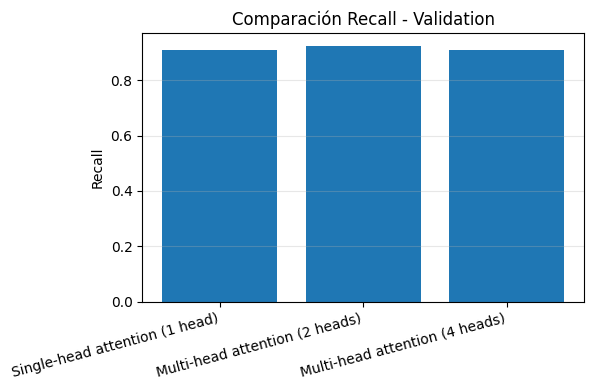

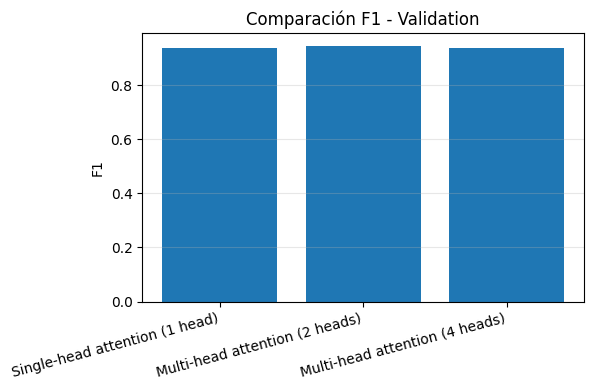

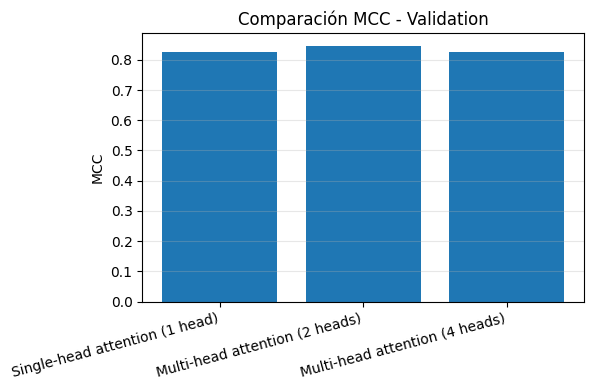

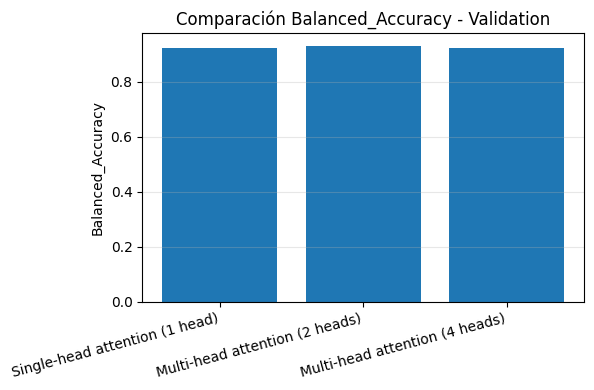

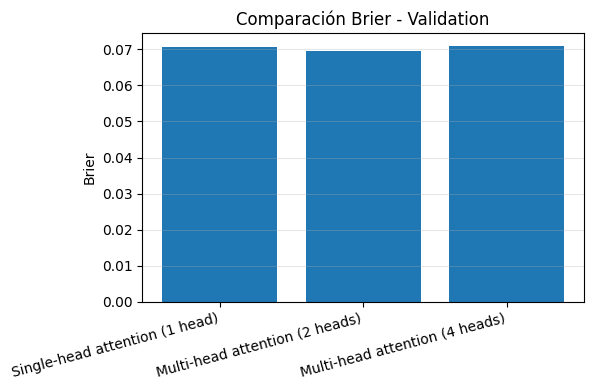

In [ ]:

plot_metrics = [
    "AUC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "Brier"
]

for metric in plot_metrics:
    plt.figure(figsize=(6, 4))
    plt.bar(
        validation_comparison_df["variant"],
        validation_comparison_df[metric]
    )
    plt.ylabel(metric)
    plt.title(f"Comparación {metric} - Validation")
    plt.xticks(rotation=15, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_ROOT,
        f"comparison_{metric}_validation.png"
    )
    save_current_figure(output_path, dpi=300)
    plt.show()

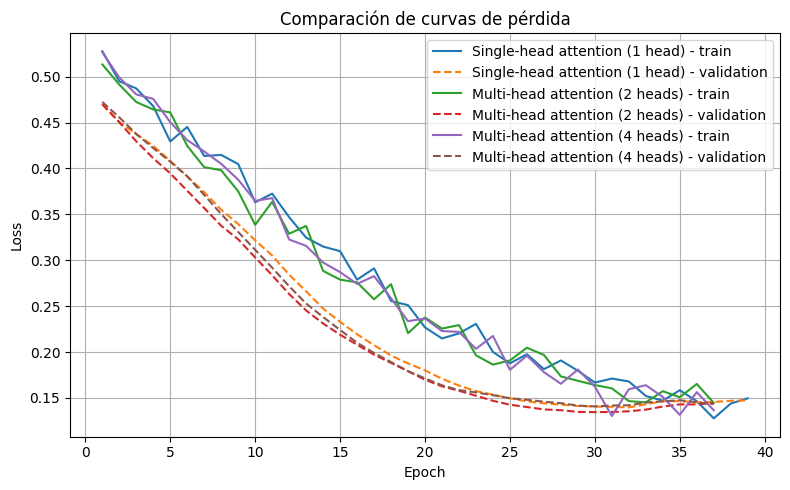

In [ ]:

all_history_df = pd.concat(
    [result["history_df"] for result in experiment_results.values()],
    ignore_index=True
)

all_history_path = os.path.join(OUTPUT_ROOT, "all_training_history_1_2_4_heads.csv")
all_history_df.to_csv(all_history_path, index=False)

plt.figure(figsize=(8, 5))

for variant in all_history_df["variant"].unique():
    sub = all_history_df[all_history_df["variant"] == variant]
    plt.plot(sub["epoch"], sub["train_loss"], label=f"{variant} - train")
    plt.plot(sub["epoch"], sub["val_loss"], linestyle="--", label=f"{variant} - validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparación de curvas de pérdida")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_comparison_path = os.path.join(OUTPUT_ROOT, "loss_curve_comparison_1_2_4_heads.png")
save_current_figure(loss_comparison_path, dpi=300)
plt.show()

In [ ]:

all_attention_by_variable_df = pd.concat(
    [result["attention_by_variable_df"] for result in experiment_results.values()],
    ignore_index=True
)

attention_variable_path = os.path.join(
    OUTPUT_ROOT,
    "attention_by_variable_comparison_1_2_4_heads.xlsx"
)
all_attention_by_variable_df.to_excel(attention_variable_path, index=False)

display(all_attention_by_variable_df)

attention_wide_df = all_attention_by_variable_df.pivot_table(
    index="variable",
    columns="variant",
    values="attention_received_mean"
).reset_index()

attention_wide_path = os.path.join(
    OUTPUT_ROOT,
    "attention_received_wide_comparison_1_2_4_heads.xlsx"
)
attention_wide_df.to_excel(attention_wide_path, index=False)

display(attention_wide_df)

,variant,variable,attention_received_mean,attention_given_mean,self_attention
0,Single-head attention (1 head),SLOPE,0.281518,0.25,0.302991
1,Single-head attention (1 head),CLC,0.256566,0.25,0.297396
2,Single-head attention (1 head),GMF,0.254215,0.25,0.271373
3,Single-head attention (1 head),UGS,0.207701,0.25,0.222510
4,Multi-head attention (2 heads),CLC,0.260588,0.25,0.285454
5,Multi-head attention (2 heads),SLOPE,0.260560,0.25,0.263728
6,Multi-head attention (2 heads),GMF,0.255475,0.25,0.281741
7,Multi-head attention (2 heads),UGS,0.223376,0.25,0.226973
8,Multi-head attention (4 heads),SLOPE,0.265669,0.25,0.275024
9,Multi-head attention (4 heads),CLC,0.263356,0.25,0.283838


variant,variable,Multi-head attention (2 heads),Multi-head attention (4 heads),Single-head attention (1 head)
0,CLC,0.260588,0.263356,0.256566
1,GMF,0.255475,0.244044,0.254215
2,SLOPE,0.260560,0.265669,0.281518
3,UGS,0.223376,0.226931,0.207701


In [ ]:

summary_rows = []

for result in experiment_results.values():
    summary_rows.append({
        "variant": result["variant_label"],
        "n_heads": result["n_heads"],
        "best_epoch": result["best_epoch"],
        "best_val_loss": result["best_val_loss"],
        "best_threshold": result["best_threshold"],
        "train_time_seconds": result["train_time_seconds"],
        "n_trainable_parameters": result["n_trainable_parameters"],
        "output_dir": result["output_dir"]
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(OUTPUT_ROOT, "summary_1_2_4_heads.xlsx")
summary_df.to_excel(summary_path, index=False)

display(summary_df)

ZIP_NAME = "GeoFormer_1_2_4_heads_comparison.zip"

if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

shutil.make_archive(
    base_name=ZIP_NAME.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_ROOT
)

print("ZIP creado:", ZIP_NAME)
print("Carpeta de resultados:", OUTPUT_ROOT)

# files.download(ZIP_NAME)

,variant,n_heads,best_epoch,best_val_loss,best_threshold,train_time_seconds,n_trainable_parameters,output_dir
0,Single-head attention (1 head),1,32,0.139691,0.29,7.776954,6213,GeoFormer_outputs_1_2_4_heads/single_head_atte...
1,Multi-head attention (2 heads),2,30,0.134533,0.23,3.448627,6213,GeoFormer_outputs_1_2_4_heads/multi_head_2_att...
2,Multi-head attention (4 heads),4,30,0.140765,0.24,3.578831,6213,GeoFormer_outputs_1_2_4_heads/multi_head_4_att...


ZIP creado: GeoFormer_1_2_4_heads_comparison.zip
Carpeta de resultados: GeoFormer_outputs_1_2_4_heads


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>